In [1]:
import sys
from pathlib import Path
from src.preprocess import load_and_prep_data
from src.config import CSV_PATH
import matplotlib.pyplot as plt

In [2]:


PROJECT_ROOT = Path("/Users/aldensantoso/Documents/plasma_research/ML Project").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import SAV_PATH, PROJECT_ROOT
from src.ingest import extract_sav_to_csv, merge_mp_tr, clean_combined_csv

mp_dir = PROJECT_ROOT
tr_csv, mp_csv = extract_sav_to_csv(str(SAV_PATH), out_dir=str(mp_dir))

combined_df = merge_mp_tr(
    mp_filepath=str(mp_csv),
    tr_filepath=str(tr_csv),
    destination_path=str(PROJECT_ROOT / "combined_plasma_data_clean.csv"),
)

cleaned_df = clean_combined_csv(
    in_csv=str(PROJECT_ROOT / "combined_plasma_data_clean.csv"),
    out_csv=str(PROJECT_ROOT / "combined_plasma_data_clean_clean.csv"),
)

'/Users/aldensantoso/Documents/plasma_research/ML Project/combined_plasma_data_clean_clean.csv'

No common shot key found. Concatenated datasets side-by-side.
mp dimensions (1051, 35)
tr dimensions (1051, 24)

[SUCCESS] New matrix created with dimensions: (1051, 47)
Saved successfully to your machine at:
--> /Users/aldensantoso/Documents/plasma_research/ML Project/combined_plasma_data_clean.csv
Saved cleaned CSV: /Users/aldensantoso/Documents/plasma_research/ML Project/combined_plasma_data_clean_clean.csv  (rows remaining: 1021)


'/Users/aldensantoso/Documents/plasma_research/ML Project/combined_plasma_data_clean_clean.csv'

In [7]:
features = [
    "PBEAM_TOT",
    "BZXR",
    "PBEAM_A",
    "PBEAM_B",
    "PBEAM_C",
    "NES",
    "TE",
    "VBEAM_A",
    "VBEAM_B",
    "VBEAM_C",
    "AVGMODEN",
    "AVGMODEF",
    "CONDE"
]

df = load_and_prep_data(
    str(CSV_PATH),
    feature_cols=features,
)

df.head()

,PBEAM_TOT,BZXR,PBEAM_A,PBEAM_B,PBEAM_C,NES,TE,VBEAM_A,VBEAM_B,VBEAM_C,AVGMODEN,AVGMODEF,CONDE,ETAU
0,1.959823,40.508120,1.959817,2.043542e-06,0.000004,6.056899e+13,1174.0201,90.174990,-0.1500,-0.075,-0.006844,518.44037,842244.4,0.099419
1,1.970917,40.507866,1.970913,0.000000e+00,0.000004,6.549727e+13,1205.2448,90.143180,-0.1500,-0.075,-0.004482,519.98740,669246.4,0.106254
2,1.967586,40.507120,1.967582,5.517562e-07,0.000004,6.932693e+13,1215.8815,90.157500,-0.1575,-0.075,-0.062992,524.86180,230481.8,0.115786
3,1.967866,40.505200,1.967861,1.103512e-06,0.000004,7.451107e+13,1228.1580,90.149994,-0.1500,-0.075,-0.123843,532.29740,141089.8,0.131372
4,1.964945,40.508766,1.964939,1.471350e-06,0.000004,7.871078e+13,1233.9232,90.127495,-0.1500,-0.075,-0.086604,529.57355,174474.2,0.102228


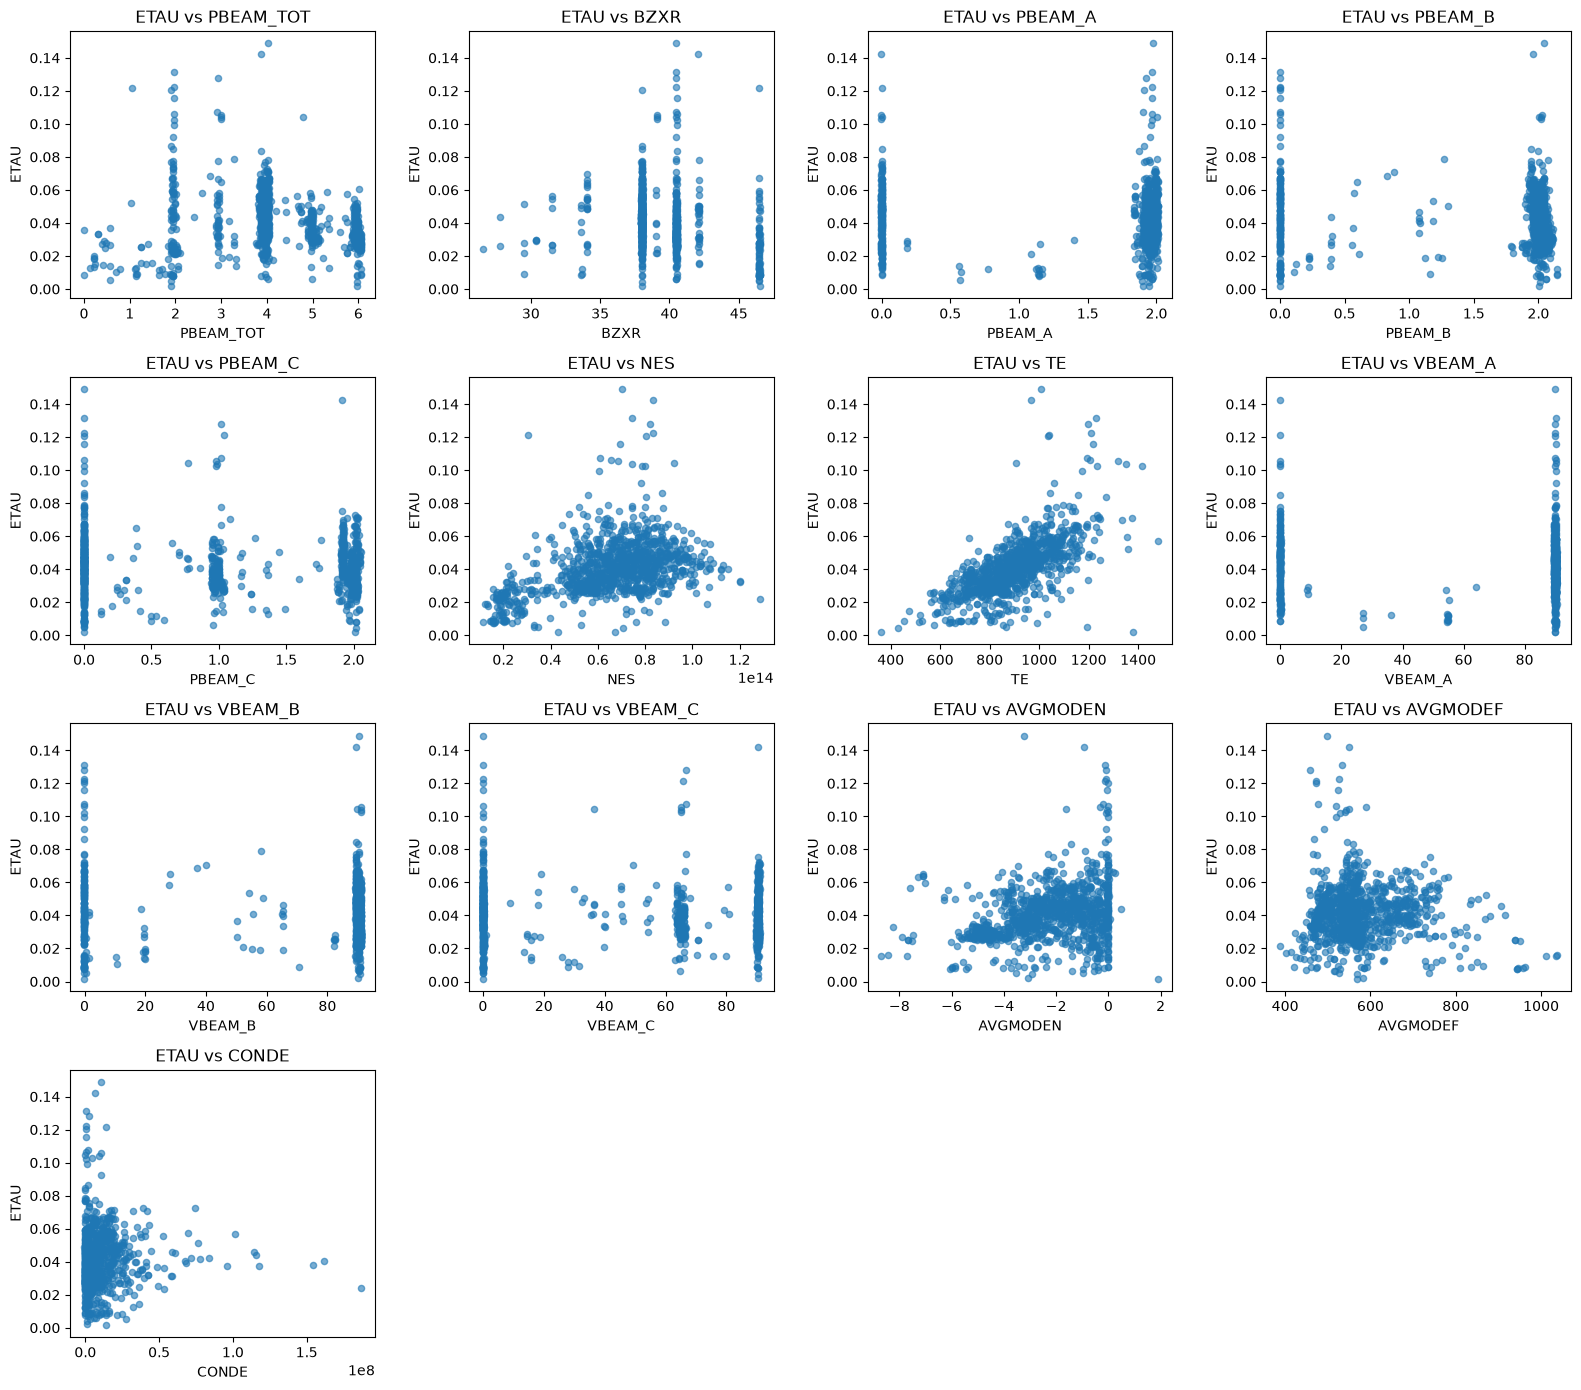

In [9]:

target_col = "ETAU"

plot_df = cleaned_df[features + [target_col]].dropna().copy()

n = len(features)
cols = 4
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.5 * rows), squeeze=False)

for idx, col in enumerate(features):
    ax = axes[idx // cols, idx % cols]
    ax.scatter(plot_df[col], plot_df[target_col], alpha=0.6, s=20)
    ax.set_xlabel(col)
    ax.set_ylabel(target_col)
    ax.set_title(f"{target_col} vs {col}")

# hide empty axes
for i in range(idx + 1, rows * cols):
    axes[i // cols, i % cols].axis("off")

plt.tight_layout()
plt.show()